# Height & Weight Prediction Using Simple Linear Regression

---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
dataset = pd.read_csv('height-weight.csv')
df = dataset
df.head(3)

,Weight,Height
0,45,120
1,58,135
2,48,123


In [9]:
df.info()
df.corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 496.0 bytes


,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


---
#### Dependent and Independent Split

In [39]:
X = df.drop('Weight', axis=1)
y = df['Weight']
X

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


---
#### Train Test Split

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=4)

---
#### Standarization

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

---
#### Model Training

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test ,y_pred)

print("mae: ", mae)
print("r2: ", r2)

mae:  6.078593679344817
r2:  0.8581293522650673


---
#### Ploting Best Fit Line

Slope or Coefficient of Weight:  [0.81633422]
Intercept:  -55.67351655529326


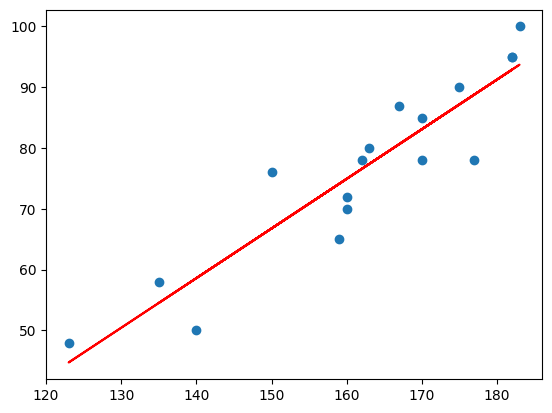

In [46]:
print("Slope or Coefficient of Weight: ", linreg.coef_)
print("Intercept: ", linreg.intercept_)

plt.scatter(X_train, y_train)
plt.plot(X_train, linreg.predict(X_train),'r')